--- Processing: test_looking_3loop_l01 ---
저장 완료: gt_raw_test_looking_3loop_l01.csv (Length: 7401)
저장 완료: gt_synced_stride20_test_looking_3loop_l01.csv (Length: 371)


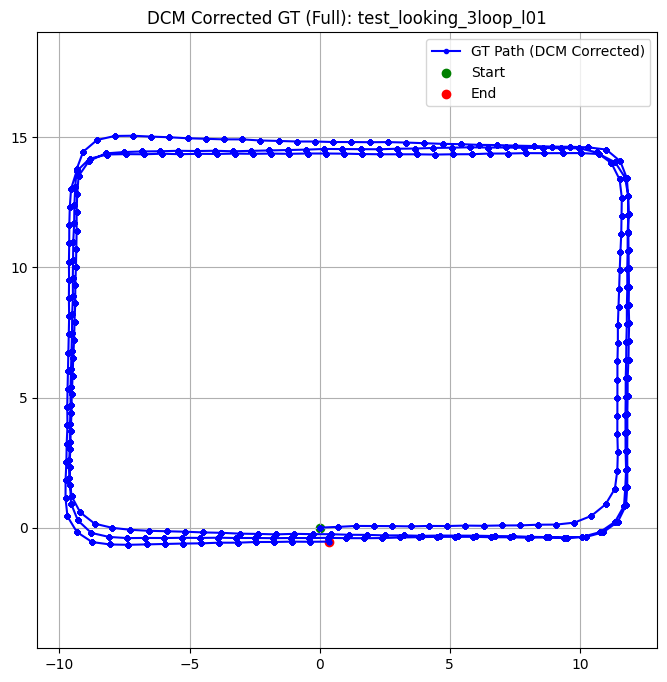

--- Processing: test_looking_3loop_r03 ---
저장 완료: gt_raw_test_looking_3loop_r03.csv (Length: 7245)
저장 완료: gt_synced_stride20_test_looking_3loop_r03.csv (Length: 363)


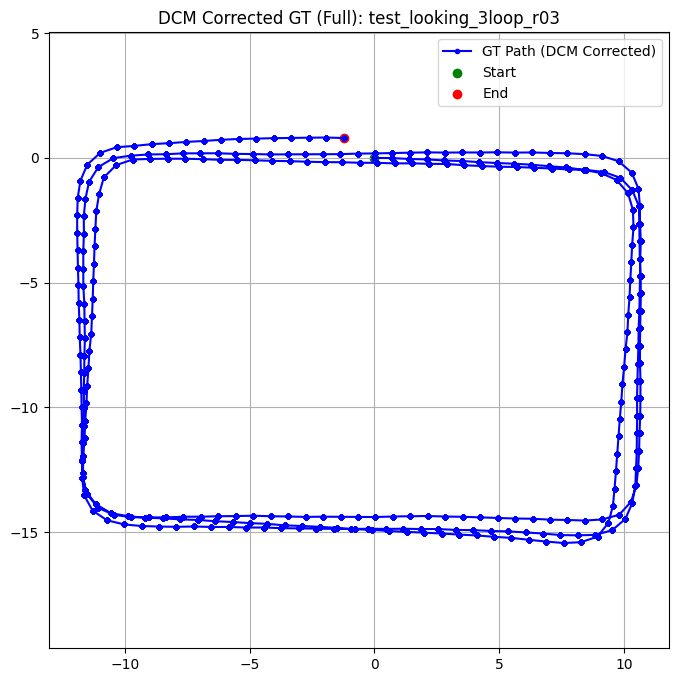

--- Processing: test3_looking_S22U ---
저장 완료: gt_raw_test3_looking_S22U.csv (Length: 4239)
저장 완료: gt_synced_stride20_test3_looking_S22U.csv (Length: 212)


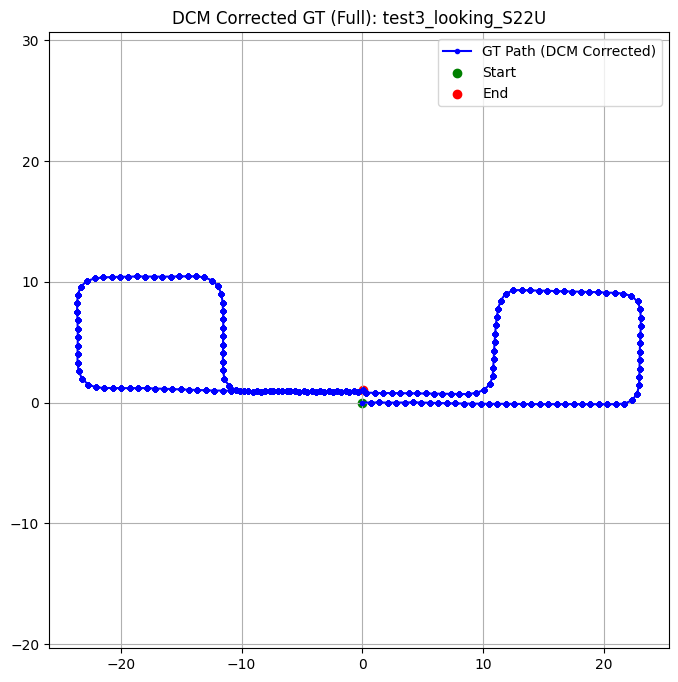


모든 작업이 완료되었습니다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.signal import find_peaks

BASE_DIR = os.getcwd()


data_paths = [
    os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_l01.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_r03.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data3", "test3_looking_S22U.csv"),
]


def load_and_preprocess_csv(file_path, skiprows=150):
    df = pd.read_csv(file_path, skiprows=skiprows, skipfooter=100, engine="python")

    df.columns = [
        "Time",
        "Accelerometer x",
        "Accelerometer y",
        "Accelerometer z",
        "Gyroscope x",
        "Gyroscope y",
        "Gyroscope z",
        "Magnetometer x",
        "Magnetometer y",
        "Magnetometer z",
        "Orientation x",
        "Orientation y",
        "Orientation z",
        "Pressure",
        "Latitude",
        "Longitude",
        "Altitude",
        "Speed_GPS",
    ]
    df["Time"] = pd.to_datetime(df["Time"], format="%Y-%m-%d %H:%M:%S.%f")
    start_dt = df["Time"].iloc[0]
    df["Elapsed Time"] = (df["Time"] - start_dt).dt.total_seconds()

    df["Acc_Norm"] = np.linalg.norm(
        df[["Accelerometer x", "Accelerometer y", "Accelerometer z"]].values, axis=1
    )
    df["Gyro_Norm"] = np.linalg.norm(
        df[["Gyroscope x", "Gyroscope y", "Gyroscope z"]].values, axis=1
    )

    return df


def generate_gt_with_correction(df, file_name, step_length=0.7, frequency=50):
    

    fs = 50.0
    dt = 1.0 / fs
    
    # pandas Series -> numpy array (복사본)
    gx = df["Gyroscope x"].to_numpy(dtype=float, copy=True)
    gy = df["Gyroscope y"].to_numpy(dtype=float, copy=True)
    gz = df["Gyroscope z"].to_numpy(dtype=float, copy=True)

    qx = df["Orientation x"].to_numpy(dtype=float, copy=True)
    qy = df["Orientation y"].to_numpy(dtype=float, copy=True)
    qz = df["Orientation z"].to_numpy(dtype=float, copy=True)
    
    # =========================
    # 3. qw 복원
    # =========================
    qw_sq = 1.0 - (qx**2 + qy**2 + qz**2)
    qw_sq = np.clip(qw_sq, 0.0, None)
    qw = np.sqrt(qw_sq)
    
    # =========================
    # 4. 쿼터니언 부호 연속성 보정
    # =========================
    for i in range(1, len(qw)):
        dot = (
            qw[i-1] * qw[i]
            + qx[i-1] * qx[i]
            + qy[i-1] * qy[i]
            + qz[i-1] * qz[i]
        )
        if dot < 0:
            qw[i] = -qw[i]
            qx[i] = -qx[i]
            qy[i] = -qy[i]
            qz[i] = -qz[i]
    
    # =========================
    # 5. pitch 계산
    # =========================
    pitch = np.arctan2(
        2.0 * (qw * qx + qy * qz),
        1.0 - 2.0 * (qx * qx + qy * qy)
    )
    
    
    pitch_deg = np.degrees(pitch)

    # =========================
    # 6. pitch 제거하여 gyro 보정
    # y축 회전 inverse 적용
    # =========================
    gyro_corr = np.zeros((len(gx), 3))

    for i in range(len(gx)):
        c = np.cos(pitch[i])
        s = np.sin(pitch[i])

        R_inv_pitch = np.array([
            [ 1,  0, 0],
            [ 0,  c,  -s],
            [ 0,  s,  c]
        ])

        g = np.array([gx[i], gy[i], gz[i]])
        gyro_corr[i] = R_inv_pitch @ g

    gx_corr = gyro_corr[:, 0]
    gy_corr = gyro_corr[:, 1]
    gz_corr = gyro_corr[:, 2]

    theta_z = np.cumsum(gz_corr) * dt
    theta_z_deg = np.degrees(theta_z)
    
    observed_total_deg = theta_z_deg[-1]
    snapped_total_deg = 90.0 * np.round(observed_total_deg / 90.0)
    #snapped_total_deg = expected_total_deg
    total_time = len(gz_corr) * dt
    bias_deg_per_sec = (observed_total_deg - snapped_total_deg) / total_time
    bias_rad_per_sec = np.radians(bias_deg_per_sec)

    # print(f"observed_total_deg = {observed_total_deg:.3f}")
    # print(f"snapped_total_deg  = {snapped_total_deg:.3f}")
    # print(f"estimated_bias     = {bias_deg_per_sec:.6f} deg/s")

    gz_corr = gz_corr - bias_rad_per_sec

    #보정 후 다시 적분
    theta_z = np.cumsum(gz_corr) * dt
    theta_z_deg = np.degrees(theta_z)

    
    # 4. 걸음 검출 및 좌표 산출
    acc_norm = df['Acc_Norm'].values - 9.81
    peaks, _ = find_peaks(acc_norm, height=0.5, distance=frequency*0.3)
    
    x, y = 0, 0
    gt_coords = []
    current_peak_idx = 0
    
    for i in range(len(df)):
        if current_peak_idx < len(peaks) and i == peaks[current_peak_idx]:
            theta = theta_z[i]
            x += step_length * np.cos(theta)
            y += step_length * np.sin(theta)
            current_peak_idx += 1
        gt_coords.append((x, y))
        
    # 5. 결과 저장
    df_gt = pd.DataFrame(gt_coords, columns=['GT_X', 'GT_Y'])
    df_gt['Time'] = df['Time']
    df_gt['Is_Step'] = 0
    df_gt.loc[peaks, 'Is_Step'] = 1
    
    # save_path = f"gt_corrected_{file_name}.csv"
    # df_gt.to_csv(save_path, index=False)
    
    return df_gt

def plot_trajectory(df_gt, title):
    plt.figure(figsize=(8, 8))
    plt.plot(df_gt['GT_X'], df_gt['GT_Y'], '.-', label='GT Path (DCM Corrected)', color='blue')
    plt.scatter(df_gt['GT_X'].iloc[0], df_gt['GT_Y'].iloc[0], color='green', label='Start')
    plt.scatter(df_gt['GT_X'].iloc[-1], df_gt['GT_Y'].iloc[-1], color='red', label='End')
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.title(title)
    plt.show()

        
   
def sync_gt_with_ai_pdr(df_gt, stride=20):
    """
    AI-PDR의 출력 주기(Stride)에 맞춰 GT 데이터를 다운샘플링합니다.
    """
    # 20, 40, 60... 인덱스의 데이터만 추출
    df_gt_synced = df_gt.iloc[::stride].copy().reset_index(drop=True)
    
    return df_gt_synced

# [위의 함수 정의 부분은 동일하게 유지]

# 동기화 및 저장 메인 루프
for p in data_paths:
    if os.path.exists(p):
        name = os.path.basename(p).replace(".csv", "")
        print(f"--- Processing: {name} ---")
        
        # 1. 원본 데이터 로드 및 전처리
        df_processed = load_and_preprocess_csv(p)
        
        # 2. 고정밀 GT 생성 (DCM 및 Bias 보정 포함)
        gt_data = generate_gt_with_correction(df_processed, name)
        
        # 3. AI-PDR Stride(20)에 맞춘 동기화 데이터 생성
        gt_synced = sync_gt_with_ai_pdr(gt_data, stride=20)
        
        # 4. 파일 저장
        # 원본 GT 저장 (50Hz 전체 경로 확인용)
        raw_save_path = f"gt_raw_{name}.csv"
        gt_data.to_csv(raw_save_path, index=False)
        
        # 동기화된 GT 저장 (AI-PDR 모델 결과와 1:1 비교용)
        synced_save_path = f"gt_synced_stride20_{name}.csv"
        gt_synced.to_csv(synced_save_path, index=False)
        
        print(f"저장 완료: {raw_save_path} (Length: {len(gt_data)})")
        print(f"저장 완료: {synced_save_path} (Length: {len(gt_synced)})")
        
        # 5. 시각화 (원본 경로 확인)
        plot_trajectory(gt_data, f"DCM Corrected GT (Full): {name}")

print("\n모든 작업이 완료되었습니다.")